# A Simple Hybrid Model for Rainfall-Runoff

This notebook moves one step beyond the Neural ODE notebook into a **hybrid model**: we keep a mechanistic nonlinear reservoir (a one-bucket rainfall-runoff model), but let a small learned residual flux correct the physics where the conceptual model is too rigid.

The state variable is catchment storage $S(t)$, and the model predicts streamflow $Q(t)$ from daily precipitation and temperature forcing:

$$
\frac{dS}{dt}
= P(t) - a\,T(t) - k\,\sigma(S)^c + r_\theta\!\bigl(S, P, T\bigr),
$$

$$
Q(t) = k\,\sigma(S)^c.
$$

Here:

- $a, k, c$ are physical parameters learned by gradient descent,
- $\sigma(S)=\log(1+e^S)$ is a smooth positivity transform,
- $r_\theta$ is a small neural-style residual flux,
- the whole model is trained on the **Leaf River** daily dataset.

We will compare three training pathways:

1. **Explicit RK4** forward solve with direct autograd through the solver
2. **Implicit Euler** with a Newton solve at every step
3. **Adjoint backpropagation**, where the forward trajectory is recomputed during the backward pass instead of storing the full graph

To keep the notebook fast enough for classroom use, we train on a contiguous 720-day segment of the Leaf River record. To use the full record, change `N_TOTAL = len(df_full)` below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)
np.random.seed(7)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

device = torch.device("cpu")
device


device(type='cpu')

## 1. Load a Leaf River segment

We use the same Leaf River rainfall-runoff dataset used elsewhere in the course. For this notebook we extract a shorter contiguous segment so that all three solver/backpropagation variants run quickly on CPU during class.


In [2]:
df_full = pd.read_csv("../../data/LeafRiverDaily.csv")
df_full.index = pd.date_range("1948-01-01", periods=len(df_full), freq="D")

N_TOTAL = 720
df = df_full.iloc[:N_TOTAL].copy()

n = len(df)
n_train = int(0.60 * n)
n_val = int(0.20 * n)
n_test = n - n_train - n_val

train_df = df.iloc[:n_train]
val_df = df.iloc[n_train:n_train + n_val]
test_df = df.iloc[n_train + n_val:]

print(f"Segment length: {n} days")
print(f"Train / Val / Test = {len(train_df)} / {len(val_df)} / {len(test_df)}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")

df.head()


Segment length: 720 days
Train / Val / Test = 432 / 144 / 144
Date range: 1948-01-01 to 1949-12-20


,Precipitation,Temperature,Streamflow
1948-01-01,0.0,4.6004,0.289951
1948-01-02,0.0,4.3092,0.244761
1948-01-03,0.0,4.3286,0.213382
1948-01-04,0.0,4.7777,0.193298
1948-01-05,0.0,2.9110,0.183258


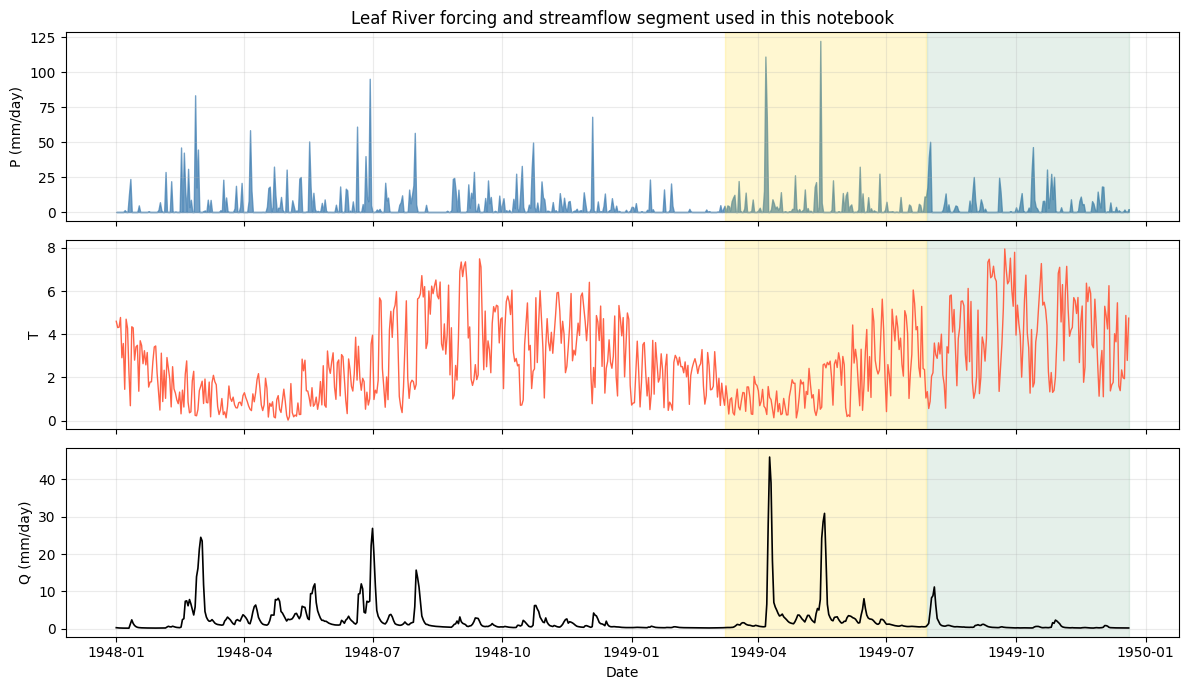

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].fill_between(df.index, df["Precipitation"], color="steelblue", alpha=0.75)
axes[0].set_ylabel("P (mm/day)")
axes[0].set_title("Leaf River forcing and streamflow segment used in this notebook")

axes[1].plot(df.index, df["Temperature"], color="tomato", lw=1.0)
axes[1].set_ylabel("T")

axes[2].plot(df.index, df["Streamflow"], color="black", lw=1.2)
axes[2].set_ylabel("Q (mm/day)")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.axvspan(df.index[n_train], df.index[n_train + n_val - 1], color="gold", alpha=0.18)
    ax.axvspan(df.index[n_train + n_val], df.index[-1], color="seagreen", alpha=0.12)

plt.tight_layout()
plt.show()


In [4]:
P = torch.tensor(df["Precipitation"].values, dtype=torch.float32, device=device)
T = torch.tensor(df["Temperature"].values, dtype=torch.float32, device=device)
Q_obs = torch.tensor(df["Streamflow"].values, dtype=torch.float32, device=device)

P_mean, P_std = P[:n_train].mean(), P[:n_train].std()
T_mean, T_std = T[:n_train].mean(), T[:n_train].std()
q_mean = torch.log1p(Q_obs[:n_train]).mean()
q_std = torch.log1p(Q_obs[:n_train]).std()

P_norm = (P - P_mean) / (P_std + 1e-6)
T_norm = (T - T_mean) / (T_std + 1e-6)
Q_norm = (torch.log1p(Q_obs) - q_mean) / (q_std + 1e-6)

forcing = torch.stack([P, T, P_norm, T_norm], dim=1)
target = Q_norm[1:]

train_slice = slice(0, n_train - 1)
val_slice = slice(n_train - 1, n_train + n_val - 1)
test_slice = slice(n_train + n_val - 1, n - 1)

print("Normalisation constants:")
print(f"  P mean/std   = {P_mean.item():.3f} / {P_std.item():.3f}")
print(f"  T mean/std   = {T_mean.item():.3f} / {T_std.item():.3f}")
print(f"  log(Q) mean/std = {q_mean.item():.3f} / {q_std.item():.3f}")


Normalisation constants:
  P mean/std   = 4.991 / 11.498
  T mean/std   = 2.595 / 1.752
  log(Q) mean/std = 0.892 / 0.670


## 2. Hybrid bucket model

The purely conceptual bucket model would be

$$
\frac{dS}{dt} = P(t) - aT(t) - kS(t)^c,
\qquad
Q(t) = kS(t)^c.
$$

That is often too rigid, so we add a learned residual flux:

$$
r_\theta(S, P, T)
= w_r \tanh\!\bigl(w_s \sigma(S) + w_p \tilde P + w_t \tilde T + b\bigr).
$$

This is deliberately small: one hidden nonlinear response, not a deep network. The point is to keep the **physics dominant** while giving the model room to learn missing processes.

We parameterize the physical coefficients with `softplus` so they remain positive during optimization:

$$
a = \operatorname{softplus}(\alpha),\quad
k = \operatorname{softplus}(\kappa),\quad
c = 1 + \operatorname{softplus}(\gamma),\quad
S_0 = \operatorname{softplus}(s_0).
$$


In [5]:
class HybridBucketCore(nn.Module):
    def __init__(self, init_theta, q_mean, q_std):
        super().__init__()
        self.raw_theta = nn.Parameter(init_theta.clone())
        self.register_buffer("q_mean", q_mean.detach().clone())
        self.register_buffer("q_std", q_std.detach().clone())

    def unpack_params(self, theta=None):
        theta = self.raw_theta if theta is None else theta
        return {
            "alpha": F.softplus(theta[0]),
            "k": F.softplus(theta[1]),
            "beta": 1.0 + F.softplus(theta[2]),
            "s0": F.softplus(theta[3]),
            "wr": theta[4],
            "ws": theta[5],
            "wp": theta[6],
            "wt": theta[7],
            "b": theta[8],
        }

    def rhs_bucket(self, s, u, theta=None):
        p = self.unpack_params(theta)
        precip, temp, p_norm, t_norm = u
        s_pos = F.softplus(s)
        z = p["ws"] * s_pos + p["wp"] * p_norm + p["wt"] * t_norm + p["b"]
        discharge = p["k"] * (s_pos + 1e-6).pow(p["beta"])
        et = p["alpha"] * temp
        residual = p["wr"] * torch.tanh(z)
        return precip - et - discharge + residual

    def drhs_ds(self, s, u, theta=None):
        p = self.unpack_params(theta)
        _, _, p_norm, t_norm = u
        s_pos = F.softplus(s)
        dsp = torch.sigmoid(s)
        z = p["ws"] * s_pos + p["wp"] * p_norm + p["wt"] * t_norm + p["b"]
        ddischarge = p["k"] * p["beta"] * (s_pos + 1e-6).pow(p["beta"] - 1.0) * dsp
        dresidual = p["wr"] * (1.0 - torch.tanh(z).pow(2)) * p["ws"] * dsp
        return -ddischarge + dresidual

    def discharge_from_state(self, s, theta=None):
        p = self.unpack_params(theta)
        return p["k"] * (F.softplus(s) + 1e-6).pow(p["beta"])

    def qhat_normalized(self, s, theta=None):
        q = self.discharge_from_state(s, theta)
        return (torch.log1p(q) - self.q_mean) / (self.q_std + 1e-6)

    def qhat_mmday(self, s, theta=None):
        return self.discharge_from_state(s, theta)


## 3. Three ways to propagate the state

### 3a. Explicit RK4 step

To make the connection to `0_neural_odes` as direct as possible, we use the same classical **RK4** stepping pattern here. That keeps the explicit solver easy to read: four slope evaluations, one weighted average, and one daily time step.

### 3b. Implicit Euler step

Implicit Euler solves

$$
S_{n+1} = S_n + \Delta t\, f(S_{n+1}, u_n, \theta),
$$

which requires a nonlinear solve at every step. Because the state is scalar, Newton iteration is very simple:

$$
G(S_{n+1}) = S_{n+1} - S_n - \Delta t\,f(S_{n+1}, u_n, \theta) = 0,
$$

$$
S_{n+1}^{(m+1)} = S_{n+1}^{(m)} - \frac{G(S_{n+1}^{(m)})}{G'(S_{n+1}^{(m)})}.
$$


In [6]:
class RK4HybridModel(nn.Module):
    def __init__(self, core, dt=1.0):
        super().__init__()
        self.core = core
        self.dt = dt

    def step(self, s, u, theta=None):
        k1 = self.core.rhs_bucket(s, u, theta)
        k2 = self.core.rhs_bucket(s + 0.5 * self.dt * k1, u, theta)
        k3 = self.core.rhs_bucket(s + 0.5 * self.dt * k2, u, theta)
        k4 = self.core.rhs_bucket(s + self.dt * k3, u, theta)
        return s + (self.dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    def rollout(self, forcing, theta=None):
        s = self.core.unpack_params(theta)["s0"]
        states = []
        preds = []
        for n in range(len(forcing) - 1):
            s = self.step(s, forcing[n], theta)
            states.append(s)
            preds.append(self.core.qhat_normalized(s, theta))
        return torch.stack(states), torch.stack(preds)

    def forward(self, forcing):
        return self.rollout(forcing)[1]


class ImplicitEulerHybridModel(nn.Module):
    def __init__(self, core, dt=1.0, n_iter=30):
        super().__init__()
        self.core = core
        self.dt = dt
        self.n_iter = n_iter

    def step(self, s, u, theta=None):
        s_next = s
        for _ in range(self.n_iter):
            G = s_next - s - self.dt * self.core.rhs_bucket(s_next, u, theta)
            dG = 1.0 - self.dt * self.core.drhs_ds(s_next, u, theta)
            s_next = s_next - G / (dG + 1e-6)
        return s_next

    def rollout(self, forcing, theta=None):
        s = self.core.unpack_params(theta)["s0"]
        states = []
        preds = []
        for n in range(len(forcing) - 1):
            s = self.step(s, forcing[n], theta)
            states.append(s)
            preds.append(self.core.qhat_normalized(s, theta))
        return torch.stack(states), torch.stack(preds)

    def forward(self, forcing):
        return self.rollout(forcing)[1]


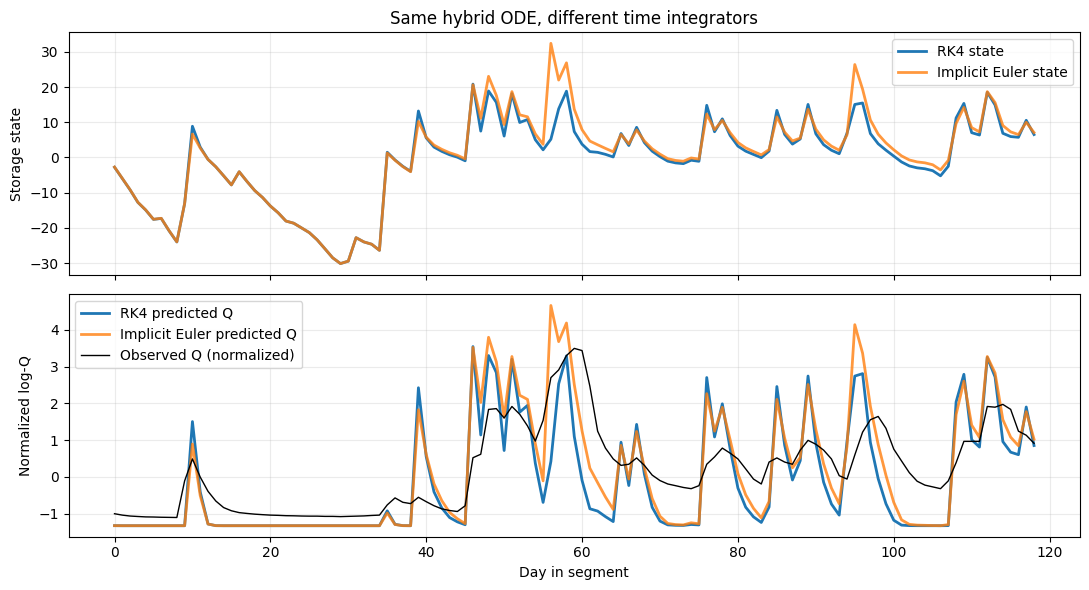

In [7]:
theta_demo = torch.tensor([0.1, -2.0, 0.1, 0.0, 0.05, 0.03, 0.04, -0.05, 0.0], dtype=torch.float32)
core_demo_rk = HybridBucketCore(theta_demo, q_mean, q_std)
core_demo_ie = HybridBucketCore(theta_demo, q_mean, q_std)
rk4_demo = RK4HybridModel(core_demo_rk)
implicit_demo = ImplicitEulerHybridModel(core_demo_ie)

with torch.no_grad():
    states_rk, q_rk = rk4_demo.rollout(forcing[:120])
    states_ie, q_ie = implicit_demo.rollout(forcing[:120])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(states_rk.detach().numpy(), label="RK4 state", lw=2)
axes[0].plot(states_ie.detach().numpy(), label="Implicit Euler state", lw=2, alpha=0.8)
axes[0].set_ylabel("Storage state")
axes[0].set_title("Same hybrid ODE, different time integrators")
axes[0].legend()

axes[1].plot(q_rk.detach().numpy(), label="RK4 predicted Q", lw=2)
axes[1].plot(q_ie.detach().numpy(), label="Implicit Euler predicted Q", lw=2, alpha=0.8)
axes[1].plot(target[:119].cpu().numpy(), color="black", lw=1, label="Observed Q (normalized)")
axes[1].set_ylabel("Normalized log-Q")
axes[1].set_xlabel("Day in segment")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Deriving the adjoint equation

Suppose the continuous model is

$$
\dot S = f(S,t,\theta),
\qquad
Q(t) = g(S(t), \theta),
$$

and we observe daily streamflow values at times $t_1,\dots,t_N$. Define our loss as

$$
\mathcal{J}(\theta)
= \sum_{i=1}^N \ell_i(S(t_i),\theta),
\qquad
\ell_i = \frac{1}{2}\left(g(S(t_i),\theta)-Q_i^{\text{obs}}\right)^2.
$$

Introduce an adjoint variable $\lambda(t)$ and the constrained Lagrangian

$$
\mathcal{L}
= \sum_{i=1}^N \ell_i(S(t_i),\theta)
 + \int_{t_0}^{t_N} \lambda(t)\,\bigl(\dot S - f(S,t,\theta)\bigr)\,dt.
$$

Varying with respect to $S$ and integrating the $\lambda\,\delta \dot S$ term by parts gives

$$
\delta \mathcal{L}
= \sum_{i=1}^N \frac{\partial \ell_i}{\partial S_i}\,\delta S_i
 + \left[\lambda\,\delta S\right]_{t_0}^{t_N}
 - \int_{t_0}^{t_N}
 \left(
 \dot\lambda + \lambda \frac{\partial f}{\partial S}
 \right)\delta S \, dt
 - \int_{t_0}^{t_N} \lambda \frac{\partial f}{\partial \theta}\,\delta \theta\,dt
 + \sum_{i=1}^N \frac{\partial \ell_i}{\partial \theta}\,\delta\theta.
$$

For the variation to vanish for arbitrary $\delta S$, the adjoint must satisfy the **backward ODE**

$$
\dot\lambda(t)
= -\lambda(t)\frac{\partial f}{\partial S}(S(t),t,\theta),
\qquad t \neq t_i,
$$

with terminal condition

$$
\lambda(t_N^+) = 0,
$$

and jump conditions at observation times

$$
\lambda(t_i^-)
= \lambda(t_i^+) + \frac{\partial \ell_i}{\partial S_i}.
$$

Since

$$
\ell_i = \frac{1}{2}(g_i - Q_i^{\text{obs}})^2,
$$

we have

$$
\frac{\partial \ell_i}{\partial S_i}
= (g_i - Q_i^{\text{obs}})\frac{\partial g_i}{\partial S_i},
\qquad
\frac{\partial \ell_i}{\partial \theta}
= (g_i - Q_i^{\text{obs}})\frac{\partial g_i}{\partial \theta}.
$$

The parameter gradient is then

$$
\frac{d\mathcal{J}}{d\theta}
= \sum_{i=1}^N \frac{\partial \ell_i}{\partial \theta}
 - \int_{t_0}^{t_N} \lambda(t)\frac{\partial f}{\partial \theta}\,dt.
$$

### Discrete version used below

In code we work on a daily mesh with a one-step map

$$
S_{n+1} = \Phi(S_n, u_n, \theta), \qquad q_n = h(S_{n+1}, \theta),
$$

so the discrete adjoint recursion is

$$
\bar S_{n+1}
= a_{n+1} + \frac{\partial \mathcal{J}}{\partial q_n}\frac{\partial h}{\partial S_{n+1}},
$$

$$
a_n = \bar S_{n+1}\frac{\partial \Phi}{\partial S_n},
$$

$$
\frac{d\mathcal{J}}{d\theta}
\mathrel{+}= \frac{\partial \mathcal{J}}{\partial q_n}\frac{\partial h}{\partial \theta}
 + \bar S_{n+1}\frac{\partial \Phi}{\partial \theta}.
$$

This is the fixed-step analogue of the continuous adjoint equation above. It recomputes the forward step during the backward pass, so it avoids storing the entire autograd graph.


In [8]:
def unpack_raw_theta(theta):
    return {
        "alpha": F.softplus(theta[0]),
        "k": F.softplus(theta[1]),
        "beta": 1.0 + F.softplus(theta[2]),
        "s0": F.softplus(theta[3]),
        "wr": theta[4],
        "ws": theta[5],
        "wp": theta[6],
        "wt": theta[7],
        "b": theta[8],
    }


def rhs_from_raw_theta(s, u, theta):
    p = unpack_raw_theta(theta)
    precip, temp, p_norm, t_norm = u
    s_pos = F.softplus(s)
    z = p["ws"] * s_pos + p["wp"] * p_norm + p["wt"] * t_norm + p["b"]
    discharge = p["k"] * (s_pos + 1e-6).pow(p["beta"])
    et = p["alpha"] * temp
    residual = p["wr"] * torch.tanh(z)
    return precip - et - discharge + residual


def discharge_from_raw_theta(s, theta):
    p = unpack_raw_theta(theta)
    return p["k"] * (F.softplus(s) + 1e-6).pow(p["beta"])


def qhat_from_raw_theta(s, theta, q_mean, q_std):
    q = discharge_from_raw_theta(s, theta)
    return (torch.log1p(q) - q_mean) / (q_std + 1e-6)


def rk4_step_raw_theta(s, u, theta, dt=1.0):
    k1 = rhs_from_raw_theta(s, u, theta)
    k2 = rhs_from_raw_theta(s + 0.5 * dt * k1, u, theta)
    k3 = rhs_from_raw_theta(s + 0.5 * dt * k2, u, theta)
    k4 = rhs_from_raw_theta(s + dt * k3, u, theta)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class RK4AdjointSolve(torch.autograd.Function):
    @staticmethod
    def forward(ctx, theta, forcing, q_mean, q_std):
        with torch.no_grad():
            s = unpack_raw_theta(theta)["s0"]
            preds = []
            states = []
            for n in range(len(forcing) - 1):
                states.append(s)
                s = rk4_step_raw_theta(s, forcing[n], theta)
                preds.append(qhat_from_raw_theta(s, theta, q_mean, q_std))
            ctx.save_for_backward(theta.detach(), forcing.detach(), torch.stack(states), q_mean.detach(), q_std.detach())
            return torch.stack(preds)

    @staticmethod
    def backward(ctx, grad_output):
        theta, forcing, states, q_mean, q_std = ctx.saved_tensors
        theta_grad = torch.zeros_like(theta)
        adjoint = torch.zeros((), dtype=theta.dtype, device=theta.device)

        with torch.enable_grad():
            for n in reversed(range(len(forcing) - 1)):
                s = states[n].detach().requires_grad_(True)
                th = theta.detach().requires_grad_(True)

                s_next = rk4_step_raw_theta(s, forcing[n], th)
                q_full = qhat_from_raw_theta(s_next, th, q_mean, q_std)

                dq_ds = torch.autograd.grad(
                    q_full,
                    s_next,
                    grad_outputs=grad_output[n],
                    retain_graph=True,
                )[0]

                q_direct = qhat_from_raw_theta(s_next.detach(), th, q_mean, q_std)
                dq_dtheta = torch.autograd.grad(
                    q_direct,
                    th,
                    grad_outputs=grad_output[n],
                    retain_graph=True,
                )[0]

                total = adjoint + dq_ds
                dphi_ds, dphi_dtheta = torch.autograd.grad(s_next, (s, th), grad_outputs=total)

                adjoint = dphi_ds.detach()
                theta_grad = theta_grad + dq_dtheta.detach() + dphi_dtheta.detach()

            th0 = theta.detach().requires_grad_(True)
            s0 = unpack_raw_theta(th0)["s0"]
            ds0_dtheta = torch.autograd.grad(s0, th0, grad_outputs=adjoint)[0]
            theta_grad = theta_grad + ds0_dtheta.detach()

        return theta_grad, None, None, None


class AdjointRK4HybridModel(nn.Module):
    def __init__(self, core):
        super().__init__()
        self.core = core

    def forward(self, forcing):
        return RK4AdjointSolve.apply(self.core.raw_theta, forcing, self.core.q_mean, self.core.q_std)


In [9]:
theta_init = torch.tensor([0.1, -2.0, 0.1, 0.0, 0.05, 0.03, 0.04, -0.05, 0.0], dtype=torch.float32)
model_check_a = RK4HybridModel(HybridBucketCore(theta_init, q_mean, q_std))
model_check_b = AdjointRK4HybridModel(HybridBucketCore(theta_init, q_mean, q_std))

loss_a = ((model_check_a.rollout(forcing[:240])[1] - target[:239]) ** 2).mean()
loss_b = ((model_check_b(forcing[:240]) - target[:239]) ** 2).mean()

loss_a.backward()
loss_b.backward()

max_grad_diff = (model_check_a.core.raw_theta.grad - model_check_b.core.raw_theta.grad).abs().max().item()
print(f"Max direct-vs-adjoint gradient difference on a short segment: {max_grad_diff:.2e}")


Max direct-vs-adjoint gradient difference on a short segment: 3.34e-06


## 5. Training helpers

All three variants use the same objective:

$$
\mathcal{J} = \frac{1}{N}\sum_n \left(\hat q_n - q_n^{\text{obs}}\right)^2,
$$

where $q_n$ is the normalized `log1p` streamflow. This stabilizes training because daily streamflow is strongly skewed.


In [10]:
def mse_by_split(pred):
    return {
        "train": ((pred[train_slice] - target[train_slice]) ** 2).mean(),
        "val": ((pred[val_slice] - target[val_slice]) ** 2).mean(),
        "test": ((pred[test_slice] - target[test_slice]) ** 2).mean(),
    }


def denorm_q(pred_norm):
    return torch.expm1(pred_norm * (q_std + 1e-6) + q_mean)


def nse(obs, pred):
    obs = np.asarray(obs)
    pred = np.asarray(pred)
    return 1.0 - np.sum((obs - pred) ** 2) / np.sum((obs - obs.mean()) ** 2)


def build_model(method):
    init_theta = torch.tensor([0.1, -2.0, 0.1, 0.0, 0.05, 0.03, 0.04, -0.05, 0.0], dtype=torch.float32, device=device)
    core = HybridBucketCore(init_theta, q_mean, q_std).to(device)
    if method == "rk4":
        return RK4HybridModel(core)
    if method == "implicit_euler":
        return ImplicitEulerHybridModel(core)
    if method == "adjoint":
        return AdjointRK4HybridModel(core)
    raise ValueError(method)


def fit_model(method, n_epochs=8, lr=0.03):
    model = build_model(method)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(n_epochs):
        opt.zero_grad()

        pred = model(forcing)

        losses = mse_by_split(pred)
        losses["train"].backward()
        opt.step()

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": losses["train"].item(),
                "val_loss": losses["val"].item(),
                "test_loss": losses["test"].item(),
            }
        )

    with torch.no_grad():
        if hasattr(model, "rollout"):
            states, pred = model.rollout(forcing)
        else:
            states = None
            pred = model(forcing)

    pred_mm = denorm_q(pred).cpu().numpy()
    q_true_mm = Q_obs[1:].cpu().numpy()

    result = {
        "model": model,
        "theta": model.core.raw_theta.detach().cpu(),
        "history": pd.DataFrame(history),
        "pred_norm": pred.detach().cpu().numpy(),
        "pred_mm": pred_mm,
        "obs_mm": q_true_mm,
        "nse_test": nse(q_true_mm[test_slice], pred_mm[test_slice]),
        "rmse_test": np.sqrt(np.mean((q_true_mm[test_slice] - pred_mm[test_slice]) ** 2)),
    }
    if states is not None:
        result["states"] = states.detach().cpu().numpy()
    return result


In [11]:
results = {
    "RK4 + direct autograd": fit_model("rk4", n_epochs=8, lr=0.03),
    "Implicit Euler + Newton": fit_model("implicit_euler", n_epochs=8, lr=0.03),
    "RK4 + adjoint backward": fit_model("adjoint", n_epochs=8, lr=0.03),
}

summary = pd.DataFrame(
    {
        name: {
            "Final train loss": res["history"]["train_loss"].iloc[-1],
            "Final val loss": res["history"]["val_loss"].iloc[-1],
            "Test RMSE (mm/day)": res["rmse_test"],
            "Test NSE": res["nse_test"],
        }
        for name, res in results.items()
    }
).T

summary.round(4)


,Final train loss,Final val loss,Test RMSE (mm/day),Test NSE
RK4 + direct autograd,1.1130,1.2828,5.1523,-11.2864
Implicit Euler + Newton,0.8421,0.9468,3.6319,-5.1049
RK4 + adjoint backward,1.1130,1.2828,5.1523,-11.2864


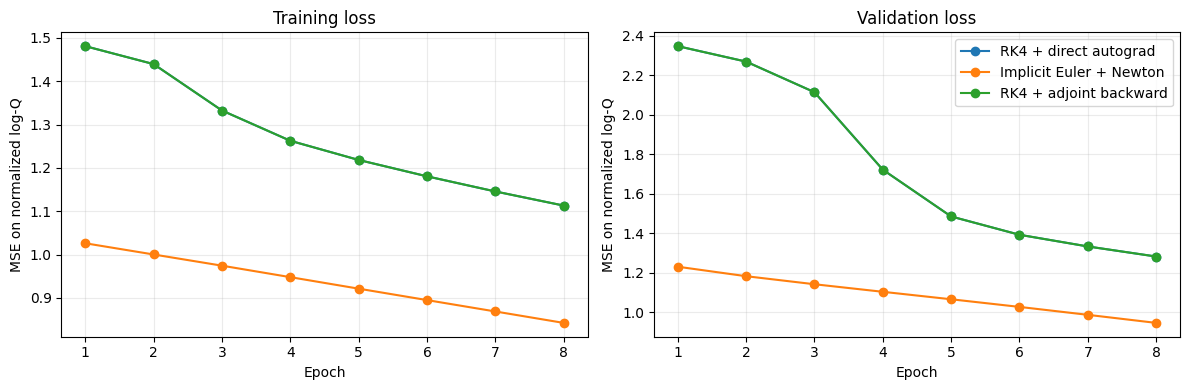

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, res in results.items():
    hist = res["history"]
    axes[0].plot(hist["epoch"], hist["train_loss"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["val_loss"], marker="o", label=name)

axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE on normalized log-Q")

axes[1].set_title("Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE on normalized log-Q")
axes[1].legend()

plt.tight_layout()
plt.show()


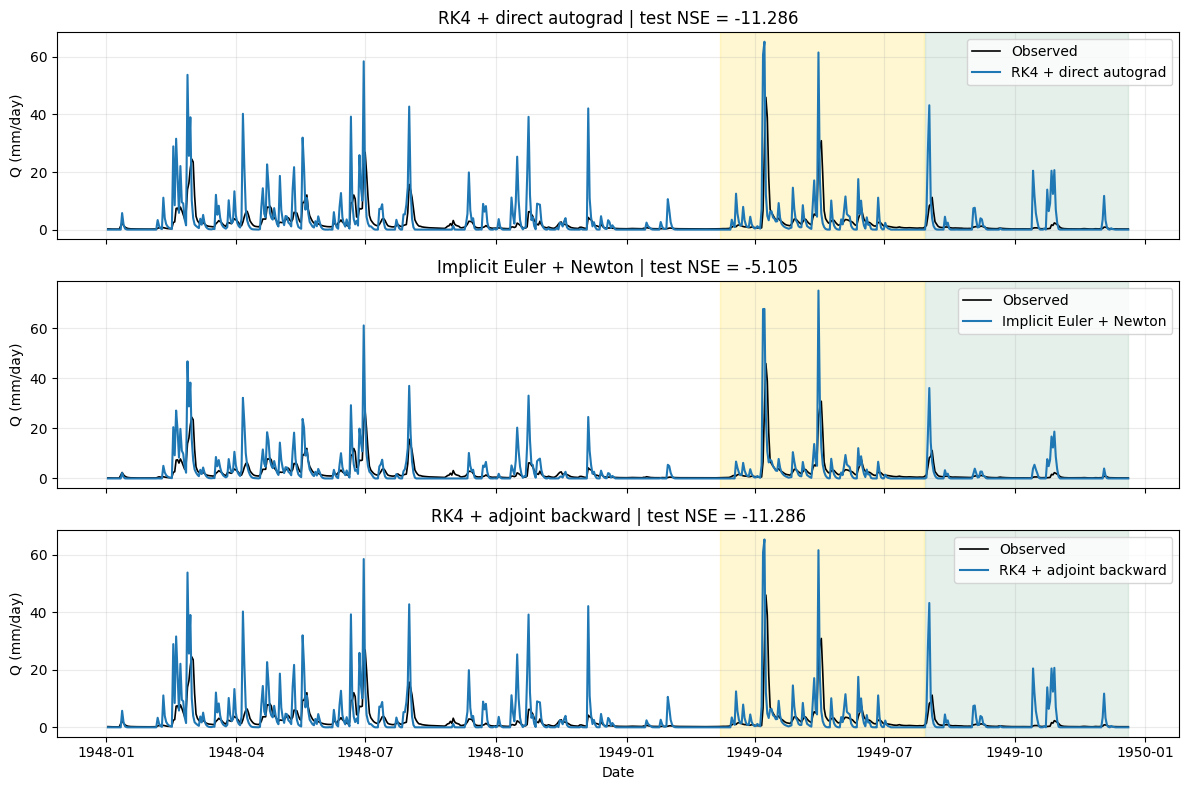

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
time_axis = df.index[1:]

for ax, (name, res) in zip(axes, results.items()):
    ax.plot(time_axis, res["obs_mm"], color="black", lw=1.2, label="Observed")
    ax.plot(time_axis, res["pred_mm"], lw=1.5, label=name)
    ax.axvspan(df.index[n_train], df.index[n_train + n_val - 1], color="gold", alpha=0.18)
    ax.axvspan(df.index[n_train + n_val], df.index[-1], color="seagreen", alpha=0.12)
    ax.set_ylabel("Q (mm/day)")
    ax.set_title(f"{name} | test NSE = {res['nse_test']:.3f}")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


In [14]:
param_names = ["alpha", "k", "beta", "s0", "wr", "ws", "wp", "wt", "b"]
param_table = pd.DataFrame(
    {name: res["theta"].numpy() for name, res in results.items()},
    index=param_names,
)
param_table.round(4)


,RK4 + direct autograd,Implicit Euler + Newton,RK4 + adjoint backward
alpha,-0.0454,0.1582,-0.0454
k,-2.2272,-2.2401,-2.2272
beta,-0.1189,-0.1396,-0.1189
s0,-0.2416,-0.2296,-0.2416
wr,0.2803,0.1989,0.2803
ws,0.2664,0.2631,0.2664
wp,-0.1455,-0.1130,-0.1455
wt,-0.1245,-0.1001,-0.1245
b,0.0655,-0.0311,0.0655


## 6. What changed between the three approaches?

### Explicit RK4

- Best when the dynamics are not especially stiff
- Easy to understand and directly differentiable
- Stores the full solver graph during backpropagation

### Implicit Euler + Newton

- More stable for stiff dynamics
- Requires solving a nonlinear equation each step
- In practice, the Newton solve becomes part of the computational graph

### Adjoint backward

- Forward solve can be treated more like a black box
- Backward pass recomputes the trajectory instead of storing all intermediate solver operations
- That trades **memory** for **extra compute**

In this notebook the state is only one-dimensional, so memory pressure is mild. The point is conceptual: once the state becomes large, the adjoint method is often what makes long continuous-time training feasible.


## 7. Takeaways

This hybrid bucket model is intentionally simple, but it already shows the main pattern used in scientific machine learning:

1. Start from a **mechanistic state equation**
2. Add a **small learned correction** where the physics is incomplete
3. Fit both physical and learned parameters together with gradient descent
4. Choose the solver and backward method based on the numerical character of the problem

This is the grey-box middle ground between:

- a pure conceptual hydrologic model with hand-tuned parameters, and
- a pure neural sequence model that ignores storage-based process structure.
